# Label Propagation: Spreading Labels Across a Similarity Graph

In most real supervised-learning settings, only a tiny fraction of the data is labeled. Labeling is expensive — a radiologist marks a few hundred scans, a moderator flags a handful of toxic posts, an astronomer classifies a few dozen galaxies — while the surrounding pool of **unlabeled** examples is enormous. Throwing away that unlabeled pool is wasteful. **Semi-supervised learning** asks a different question:

> Can we exploit the *geometry* of the unlabeled data to make sense of it, using the few labels we have as seeds?

Label propagation answers that by treating the dataset as a **graph**. Every sample is a node. The edge weight between two nodes measures how similar they are in feature space (commonly via an RBF kernel on Euclidean distance). The labeled nodes inject their class into the graph, and the labels **diffuse** to their neighbours, then to neighbours-of-neighbours, and so on, until the dynamics settle. At convergence, every unlabeled node carries a soft distribution over classes — and the argmax is the predicted label.

This relies on the **manifold assumption**: points that lie close on the data manifold usually share a label. When that assumption holds, a handful of seeds is enough to label the entire dataset reliably. When it fails (labeled classes are mixed together in feature space), no amount of propagation will rescue you.

## The algorithm at a glance

![Label Propagation algorithm flowchart](flowchart.png)

In this notebook we go all the way from "what does the math look like?" to a real-world semi-supervised benchmark — handwritten digit recognition with only a **handful** of labeled examples per digit.

## The mathematics

Let $n$ be the total number of samples, $c$ the number of classes, and $x_1, \dots, x_n \in \mathbb{R}^d$ the feature vectors. Some rows of the label vector $y \in \{-1, 0, 1, \dots, c-1\}^n$ are genuine class indices; the rest are $-1$ (meaning "unknown, please fill me in").

### 1. Build the similarity graph

We use a Gaussian / RBF kernel with bandwidth $\sigma$:

$$
W_{ij} = \exp\!\left(-\frac{\lVert x_i - x_j \rVert^2}{2\sigma^2}\right), \qquad W_{ii} = 0.
$$

The bandwidth $\sigma$ controls *how far* similarity reaches: small $\sigma$ makes every node nearly isolated; large $\sigma$ makes every node look like every other node.

### 2. Row-normalise into a transition matrix

$$
T_{ij} = \frac{W_{ij}}{\sum_k W_{ik}}.
$$

Row $i$ of $T$ is a probability distribution over the other samples: "if I were a random walker standing at node $i$, here is where I'd hop next." Propagation is literally a weighted one-step averaging of labels along these transitions.

### 3. Initial label matrix

Let $F^{(0)} \in \mathbb{R}^{n \times c}$ be the one-hot encoding of the known labels, with all-zero rows for unlabeled samples. Call this $Y_0$; we will need it at every iteration.

### 4. Iterate the propagation update

$$
F^{(t+1)} \;=\; \alpha\, T F^{(t)} \;+\; (1 - \alpha)\, Y_0
$$

with a **clamping** step that *overrides* the labeled rows of $F^{(t+1)}$ back to their one-hot ground truth:

$$
F^{(t+1)}_{i,\cdot} \;\leftarrow\; Y_{0, i, \cdot} \qquad \text{for every labeled index } i.
$$

The parameter $\alpha \in (0, 1)$ (our package calls it `spread`) blends "listen to my neighbours" ($T F^{(t)}$) with "remember the original seeds" ($Y_0$). Clamping is what keeps the seed labels from being overwritten by a confused majority of unlabeled neighbours. Without it, a minority-class seed surrounded by majority-class neighbours will be drowned out within a few iterations.

### 5. Convergence and prediction

We stop when $\lVert F^{(t+1)} - F^{(t)} \rVert_F < \text{tol}$ or after `max_iterations`. The hard prediction is

$$
\hat{y}_i = \arg\max_k F^{(T)}_{i,k}.
$$

Because $T$ is row-stochastic and $\alpha < 1$, the iteration is a contraction mapping: it converges geometrically to the closed-form fixed point $F^{\ast} = (1 - \alpha)\, (I - \alpha T)^{-1} Y_0$. We just use the iterative form because it plays nicely with the clamping step and is cheap to run.

## The `GraphLabelPropagation` API

The class we implement lives at [`src/mlpackage/unsupervised_learning/label_propagation.py`](../../../src/mlpackage/unsupervised_learning/label_propagation.py). Here is how its constructor arguments map to the symbols above and to the notation other label-propagation references use.

| Our argument | Math symbol | Common literature name | What it controls |
|---|---|---|---|
| `spread` | $\alpha$ | `alpha` | How strongly information from neighbours overrides the seed signal each step. Must be in $(0, 1)$. |
| `bandwidth` | $\sigma$ | `sigma` / `gamma=1/(2 sigma^2)` | RBF kernel width. Sets the effective neighbourhood radius. |
| `max_iterations` | — | `max_iter` | Upper bound on sweeps before bailing out. |
| `convergence_tol` | — | `tol` | Frobenius-norm threshold on $\Vert F^{(t+1)} - F^{(t)} \Vert$ for early stopping. |
| `clamp_labelled` | — | (always-on in most libraries) | Whether to reset labeled rows to their one-hot ground truth after each iteration. Leave `True` for standard behaviour. |

After calling `.fit(X, y)` (where `y[i] == -1` means "unlabeled") the instance exposes:

- `labels_` — hard predictions for every row, selected as $\arg\max$ over $F^{(\text{final})}$.
- `distribution_` — the full soft matrix $F^{(\text{final})} \in \mathbb{R}^{n \times c}$, so you can see *confidence*, not just the top-1 choice.
- `transition_` — the row-normalised matrix $T$, useful for sanity-checking the graph.
- `classes_` — the sorted vector of class indices the model actually saw in `y`.

With the theory in hand, it's time to put it to work on a real dataset.

## The dataset: sklearn handwritten digits

We'll use the **sklearn handwritten digits** dataset — the canonical testbed for semi-supervised learning, going back to Zhu and Ghahramani's original 2002 label-propagation paper. Each sample is an 8-by-8 grayscale image of a digit (0 through 9), flattened into a 64-dimensional pixel-intensity vector. The full dataset has 1,797 samples across 10 perfectly balanced classes.

Because label propagation requires a dense $n \times n$ affinity matrix, we'll **stratified-subsample to 500 samples** (roughly 50 per class). This keeps everything in-memory and the whole notebook executes in well under a minute.

| Property | Value |
|---|---|
| Source | `sklearn.datasets.load_digits` (bundled with scikit-learn) |
| Samples | 1,797 total, subsampled to **500** (stratified, 50 per class) |
| Classes | 10 (digits 0-9) |
| Features | 64 pixel intensities in `[0, 16]` |
| Semi-supervised setup | 3 labeled samples per class = **30 labeled, 470 unlabeled** (6%) |

The semi-supervised story here is immediate: "I showed the algorithm three pictures of each digit. Can it figure out what the other 470 are?"

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
while _here != _here.parent and not (_here / "pyproject.toml").exists():
    _here = _here.parent
REPO_ROOT = _here
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.semi_supervised import LabelSpreading as SKLabelSpreading
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

from mlpackage.unsupervised_learning import GraphLabelPropagation

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3})

rng = np.random.default_rng(0)

digits = load_digits()
X_full, y_full = digits.data, digits.target
images_full = digits.images

N_PER_CLASS = 50
CLASSES = np.arange(10)

indices = []
for c in CLASSES:
    cls_idx = np.where(y_full == c)[0]
    chosen = rng.choice(cls_idx, size=N_PER_CLASS, replace=False)
    indices.append(chosen)
indices = np.concatenate(indices)
rng.shuffle(indices)

X = X_full[indices]
y_true = y_full[indices]
images = images_full[indices]

print(f"Full dataset:         X shape = {X_full.shape}, {len(CLASSES)} classes")
print(f"Stratified subsample: X shape = {X.shape}, {N_PER_CLASS} per class")
print(f"Class counts: {np.bincount(y_true).tolist()}")
print(f"Pixel value range: [{X.min():.0f}, {X.max():.0f}]")

Full dataset:         X shape = (1797, 64), 10 classes
Stratified subsample: X shape = (500, 64), 50 per class
Class counts: [50, 50, 50, 50, 50, 50, 50, 50, 50, 50]
Pixel value range: [0, 16]


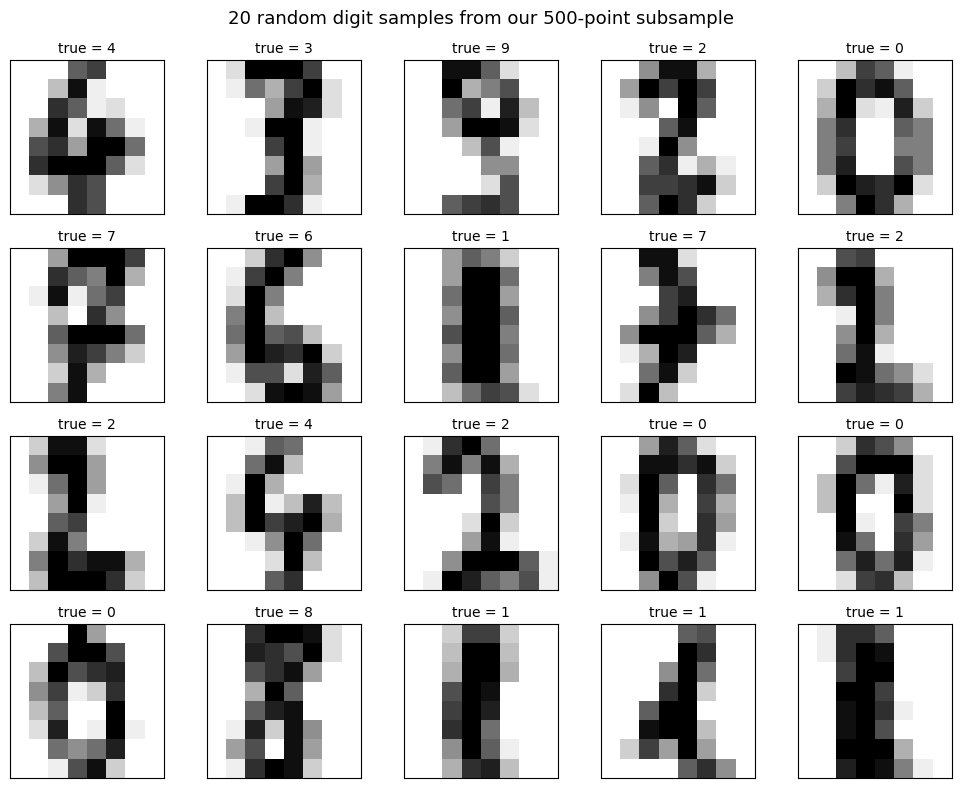

In [2]:
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
vis_rng = np.random.default_rng(7)
sample_ids = vis_rng.choice(len(X), size=20, replace=False)

for ax, idx in zip(axes.ravel(), sample_ids):
    ax.imshow(images[idx], cmap="gray_r", interpolation="nearest")
    ax.set_title(f"true = {y_true[idx]}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

fig.suptitle("20 random digit samples from our 500-point subsample", fontsize=13)
plt.tight_layout()
plt.show()

## Standardizing the pixel intensities

Every pixel already lives on the same `[0, 16]` scale, so standardizing isn't strictly required. But RBF distances are a **sum of squared coordinate differences**, and some pixels (the ones in the middle of the image where strokes land) vary a lot more than others (the always-black corners). Without scaling, the high-variance pixels dominate the pairwise distances and the quiet corners barely contribute. Standardizing each pixel to zero mean and unit variance puts every coordinate on equal footing.

We also use exactly the same scaling convention as the DBSCAN and K-means notebooks in this folder, so the three notebooks share a consistent preprocessing story.

Raw X:      mean = 4.874, std = 6.015, range = [0.00, 16.00]
Scaled X:   mean = -0.000, std = 0.952, range = [-2.79, 22.34]


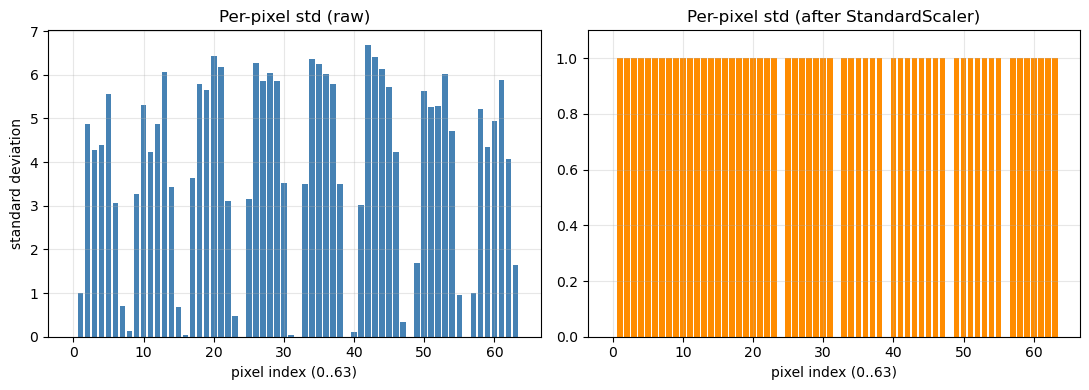

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Raw X:      mean = {X.mean():.3f}, std = {X.std():.3f}, range = [{X.min():.2f}, {X.max():.2f}]")
print(f"Scaled X:   mean = {X_scaled.mean():.3f}, std = {X_scaled.std():.3f}, range = [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")

pixel_stds_raw = X.std(axis=0)
pixel_stds_scaled = X_scaled.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(np.arange(64), pixel_stds_raw, color="steelblue")
axes[0].set_title("Per-pixel std (raw)")
axes[0].set_xlabel("pixel index (0..63)")
axes[0].set_ylabel("standard deviation")
axes[1].bar(np.arange(64), pixel_stds_scaled, color="darkorange")
axes[1].set_title("Per-pixel std (after StandardScaler)")
axes[1].set_xlabel("pixel index (0..63)")
axes[1].set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## Creating the semi-supervised setup

The original dataset comes fully labeled, which would be no fun. We simulate a realistic SSL scenario by deliberately **hiding** most of the labels:

- Pick **`k = 3`** random samples from each of the 10 classes, keep their labels (so, 30 seeds total).
- Overwrite the remaining 470 rows with `-1`, our package's "unknown" sentinel.

That's **6% labeled, 94% unknown** — an aggressive test. A dumb guesser would get about 10% accuracy (1-in-10 chance per digit). A purely supervised model trained on just these 30 seeds has very little to work with. Label propagation, on the other hand, gets to peek at the geometry of all 500 points while deciding.

To make the setup visible, we'll project the 64-D data into 2D with PCA and show all 500 points coloured by their *true* label, with the 30 seeded points highlighted as large black-ringed markers. Keep in mind: the algorithm **never sees the colours** of the 470 background dots — it only sees their positions and knows they're unlabeled.

Labeled:   30 / 500 (6.0%)
Unlabeled: 470 / 500 (94.0%)
Labels per class among seeds: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
2D PCA captures 22.5% of the variance (12.5% + 10.0%)


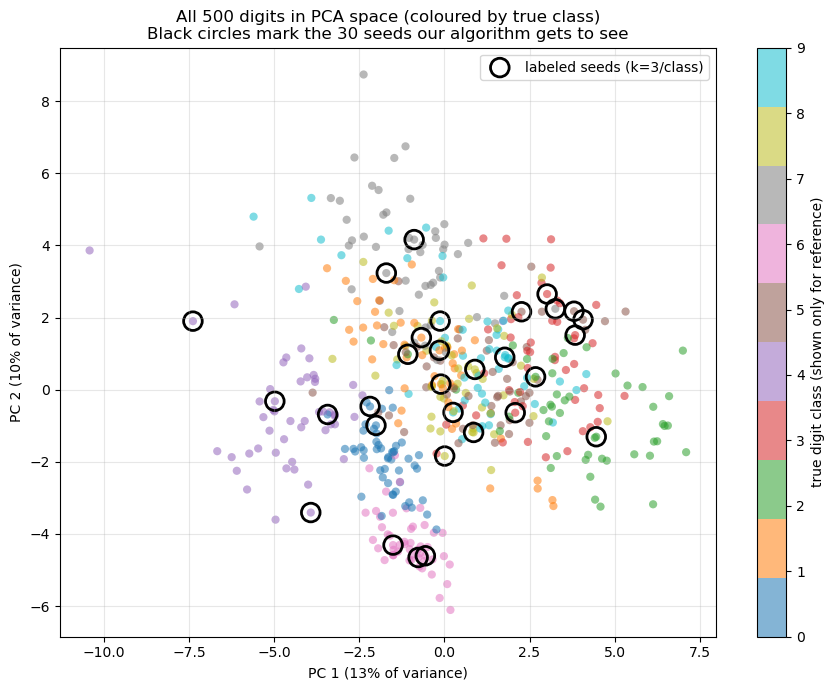

In [4]:
def make_mask(y_true, k, seed):
    """Return a semi-supervised label vector with k labels per class (others = -1)."""
    rng_local = np.random.default_rng(seed)
    y_masked = np.full_like(y_true, -1)
    for c in np.unique(y_true):
        cls_idx = np.where(y_true == c)[0]
        chosen = rng_local.choice(cls_idx, size=k, replace=False)
        y_masked[chosen] = c
    return y_masked


K_LABELS_PER_CLASS = 3
y_masked = make_mask(y_true, K_LABELS_PER_CLASS, seed=42)
labeled_idx = np.where(y_masked != -1)[0]
unlabeled_idx = np.where(y_masked == -1)[0]
print(f"Labeled:   {len(labeled_idx)} / {len(y_masked)} ({100 * len(labeled_idx) / len(y_masked):.1f}%)")
print(f"Unlabeled: {len(unlabeled_idx)} / {len(y_masked)} ({100 * len(unlabeled_idx) / len(y_masked):.1f}%)")
print(f"Labels per class among seeds: {np.bincount(y_masked[labeled_idx]).tolist()}")

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f"2D PCA captures {explained.sum():.1%} of the variance ({explained[0]:.1%} + {explained[1]:.1%})")

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_true, cmap="tab10", s=35, alpha=0.55, edgecolor="none",
)
ax.scatter(
    X_pca[labeled_idx, 0], X_pca[labeled_idx, 1],
    facecolor="none", edgecolor="black", linewidth=2.0, s=180,
    label=f"labeled seeds (k={K_LABELS_PER_CLASS}/class)",
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label("true digit class (shown only for reference)")
ax.set_xlabel(f"PC 1 ({explained[0]:.0%} of variance)")
ax.set_ylabel(f"PC 2 ({explained[1]:.0%} of variance)")
ax.set_title(
    f"All 500 digits in PCA space (coloured by true class)\n"
    f"Black circles mark the {len(labeled_idx)} seeds our algorithm gets to see"
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Building and visualizing the similarity graph

The whole algorithm pivots on the affinity matrix $W$. If the underlying graph cleanly separates the classes (strong edges *within* classes, weak edges *between* classes), propagation works beautifully. If not, labels bleed across class boundaries.

**Choosing the bandwidth.** The textbook heuristic is to set $\sigma$ to the *median* pairwise distance. In low dimensions this usually works. In 64-D pixel space it does not: the curse of dimensionality makes almost every pair of points sit at roughly the same medium distance, so an RBF with $\sigma = \text{median}$ assigns nearly-equal similarity to within-class and between-class pairs — the graph has no structure.

The fix is to use a **much tighter** bandwidth, one that only declares *close* neighbours as similar. We'll confirm this visually below: at $\sigma = 1.0$ (roughly median / 10), the affinity matrix sorted by true class shows a clear block-diagonal pattern; at $\sigma = \text{median}$, it's almost uniform. We use the same `_rbf_similarity` helper the package uses internally so the visualization is exactly what the algorithm actually sees.

Median pairwise distance: 9.825
With bandwidth = median_dist:
  average same-class similarity       = 6.960e-01
  average different-class similarity  = 5.740e-01
  ratio                                = 1.21x

In 64-dim pixel space, almost every pair has roughly the median distance, so
the RBF with bandwidth = median produces an almost uniform graph -- structure
is invisible. This is a classic curse-of-dimensionality effect. We need a much
tighter bandwidth so that close neighbours stand out from the background.

Chosen bandwidth = 1.0  (roughly median / 10)
At this bandwidth:
  same-class / different-class similarity ratio = 17571x
  transition matrix row sums == 1? True


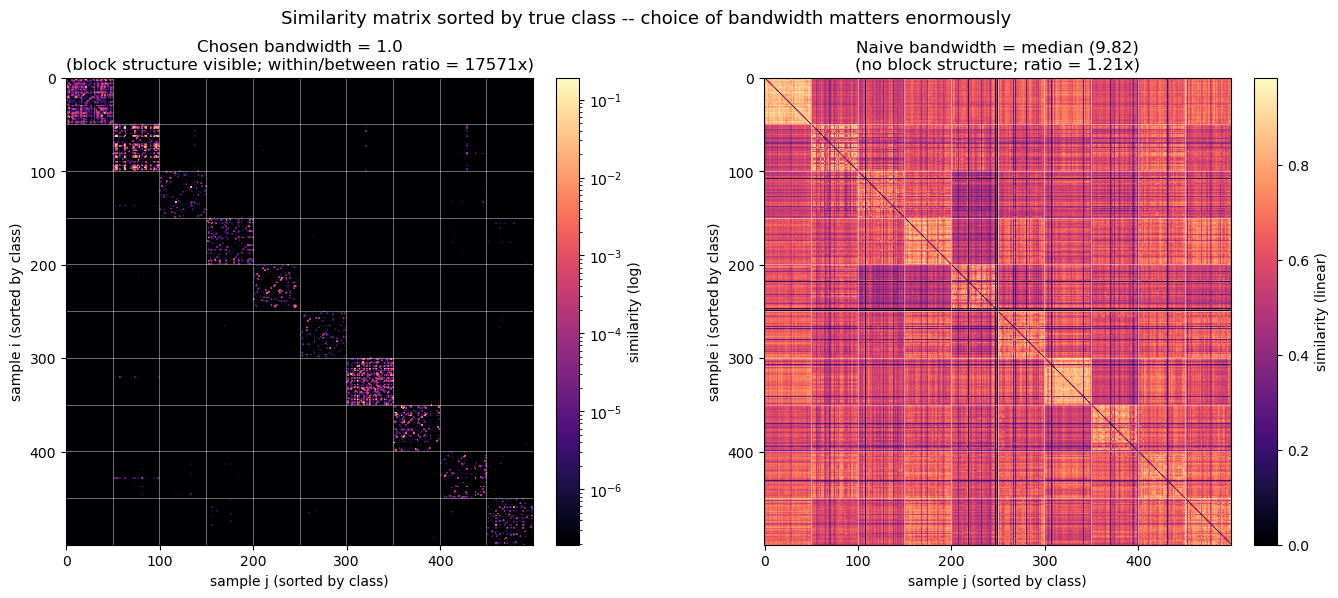

In [5]:
from matplotlib.colors import LogNorm

from mlpackage.unsupervised_learning.label_propagation import (
    _pairwise_squared_distances,
    _rbf_similarity,
    _row_normalise,
)

sq_dists = _pairwise_squared_distances(X_scaled)
pairwise = np.sqrt(np.clip(sq_dists, 0, None))
iu = np.triu_indices(pairwise.shape[0], k=1)
median_dist = float(np.median(pairwise[iu]))

def within_between_ratio(W, y):
    wc, bc = [], []
    for c in np.unique(y):
        idx_c = np.where(y == c)[0]
        idx_nc = np.where(y != c)[0]
        wc.append(W[np.ix_(idx_c, idx_c)].mean())
        bc.append(W[np.ix_(idx_c, idx_nc)].mean())
    return float(np.mean(wc)), float(np.mean(bc))

W_median = _rbf_similarity(X_scaled, median_dist)
wc_m, bc_m = within_between_ratio(W_median, y_true)

print(f"Median pairwise distance: {median_dist:.3f}")
print(f"With bandwidth = median_dist:")
print(f"  average same-class similarity       = {wc_m:.3e}")
print(f"  average different-class similarity  = {bc_m:.3e}")
print(f"  ratio                                = {wc_m / max(bc_m, 1e-12):.2f}x")
print()
print("In 64-dim pixel space, almost every pair has roughly the median distance, so")
print("the RBF with bandwidth = median produces an almost uniform graph -- structure")
print("is invisible. This is a classic curse-of-dimensionality effect. We need a much")
print("tighter bandwidth so that close neighbours stand out from the background.")

BANDWIDTH = 1.0
print(f"\nChosen bandwidth = {BANDWIDTH}  (roughly median / 10)")

W = _rbf_similarity(X_scaled, BANDWIDTH)
T = _row_normalise(W)
wc_c, bc_c = within_between_ratio(W, y_true)
print(f"At this bandwidth:")
print(f"  same-class / different-class similarity ratio = {wc_c / max(bc_c, 1e-12):.0f}x")
print(f"  transition matrix row sums == 1? {np.allclose(T.sum(axis=1), 1.0)}")

sort_idx = np.argsort(y_true, kind="stable")
y_sorted = y_true[sort_idx]
W_sorted_chosen = W[np.ix_(sort_idx, sort_idx)]
W_sorted_median = W_median[np.ix_(sort_idx, sort_idx)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
boundaries = np.cumsum(np.bincount(y_sorted))[:-1]

vmin = max(W_sorted_chosen.max() * 1e-6, 1e-20)
im0 = axes[0].imshow(W_sorted_chosen + vmin, cmap="magma", aspect="equal",
                     norm=LogNorm(vmin=vmin, vmax=W_sorted_chosen.max()))
axes[0].set_title(f"Chosen bandwidth = {BANDWIDTH}\n(block structure visible; within/between ratio = {wc_c / max(bc_c, 1e-12):.0f}x)")
axes[0].set_xlabel("sample j (sorted by class)")
axes[0].set_ylabel("sample i (sorted by class)")
axes[0].grid(False)
for b in boundaries:
    axes[0].axhline(b - 0.5, color="white", linewidth=0.5, alpha=0.6)
    axes[0].axvline(b - 0.5, color="white", linewidth=0.5, alpha=0.6)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="similarity (log)")

im1 = axes[1].imshow(W_sorted_median, cmap="magma", aspect="equal")
axes[1].set_title(f"Naive bandwidth = median ({median_dist:.2f})\n(no block structure; ratio = {wc_m / max(bc_m, 1e-12):.2f}x)")
axes[1].set_xlabel("sample j (sorted by class)")
axes[1].set_ylabel("sample i (sorted by class)")
axes[1].grid(False)
for b in boundaries:
    axes[1].axhline(b - 0.5, color="white", linewidth=0.5, alpha=0.6)
    axes[1].axvline(b - 0.5, color="white", linewidth=0.5, alpha=0.6)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="similarity (linear)")

fig.suptitle("Similarity matrix sorted by true class -- choice of bandwidth matters enormously", fontsize=13)
plt.tight_layout()
plt.show()

## Fitting `GraphLabelPropagation`

Time to run the algorithm. We fit on `X_scaled` (all 500 points) together with `y_masked` (only 30 of them have a genuine class index; the other 470 are `-1`). The classifier will spread the 30 seed labels through the graph until convergence and return a full prediction for every point.

We use:

- `spread = 0.9` — a standard choice: most of the time, trust your neighbours; keep 10% of the original seed signal.
- `bandwidth = median_dist` — the heuristic we computed above.
- `max_iterations = 1000`, `convergence_tol = 1e-4` — defaults.

Accuracy is computed on the **470 unlabeled points only**, because judging the seeds is trivial (they're clamped to ground truth by construction).

Unlabeled accuracy (headline number): 88.5%  (416 of 470)
Overall accuracy:                     89.2%  (446 of 500)
Mean prediction confidence: 0.255   (min 0.000, max 1.000)


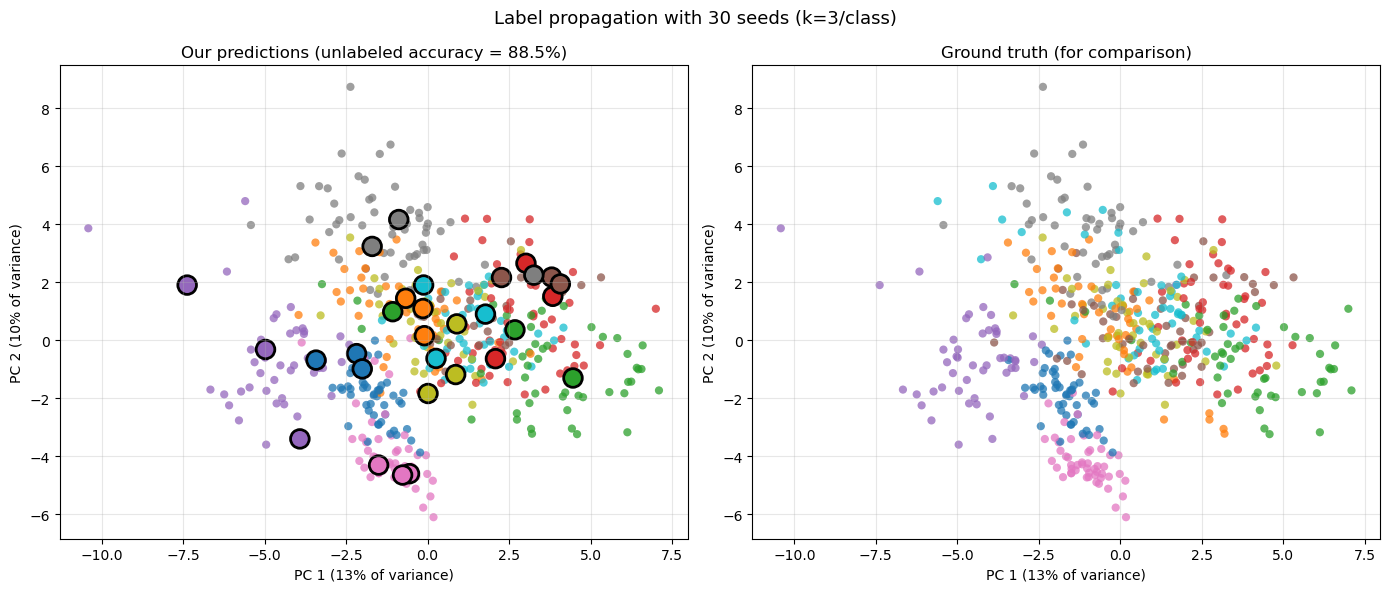

In [6]:
model = GraphLabelPropagation(
    spread=0.9,
    bandwidth=BANDWIDTH,
    max_iterations=1000,
    convergence_tol=1e-4,
).fit(X_scaled, y_masked)

y_pred = model.labels_
confidence = model.distribution_.max(axis=1)

acc_unlabeled = accuracy_score(y_true[unlabeled_idx], y_pred[unlabeled_idx])
acc_overall = accuracy_score(y_true, y_pred)

print(f"Unlabeled accuracy (headline number): {acc_unlabeled:.1%}  ({int(acc_unlabeled * len(unlabeled_idx))} of {len(unlabeled_idx)})")
print(f"Overall accuracy:                     {acc_overall:.1%}  ({int(acc_overall * len(y_true))} of {len(y_true)})")
print(f"Mean prediction confidence: {confidence.mean():.3f}   (min {confidence.min():.3f}, max {confidence.max():.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    X_pca[unlabeled_idx, 0], X_pca[unlabeled_idx, 1],
    c=y_pred[unlabeled_idx], cmap="tab10", s=35, alpha=0.75, edgecolor="none",
    vmin=0, vmax=9,
)
axes[0].scatter(
    X_pca[labeled_idx, 0], X_pca[labeled_idx, 1],
    c=y_true[labeled_idx], cmap="tab10", s=180, edgecolor="black", linewidth=2.0,
    vmin=0, vmax=9,
)
axes[0].set_xlabel(f"PC 1 ({explained[0]:.0%} of variance)")
axes[0].set_ylabel(f"PC 2 ({explained[1]:.0%} of variance)")
axes[0].set_title(f"Our predictions (unlabeled accuracy = {acc_unlabeled:.1%})")

axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_true, cmap="tab10", s=35, alpha=0.75, edgecolor="none",
    vmin=0, vmax=9,
)
axes[1].set_xlabel(f"PC 1 ({explained[0]:.0%} of variance)")
axes[1].set_ylabel(f"PC 2 ({explained[1]:.0%} of variance)")
axes[1].set_title("Ground truth (for comparison)")

fig.suptitle(f"Label propagation with {len(labeled_idx)} seeds (k={K_LABELS_PER_CLASS}/class)", fontsize=13)
plt.tight_layout()
plt.show()

## Watching labels spread through the graph

The previous plots showed only the *final* answer. Let's open the black box and actually **watch** the labels spread over time. We'll manually reproduce the propagation loop and take a snapshot of the soft distribution $F$ at several checkpoints.

For each snapshot we'll plot the PCA scatter with:

- **colour** = current $\arg\max F_{i,\cdot}$ (i.e., the point's current best guess),
- **opacity** = $\max F_{i,\cdot}$ (how *confident* that guess is).

At iteration 0, only the 30 seeds have any colour (max = 1); the 470 unlabeled points are transparent. After a few iterations, confidence blooms outward along strong-affinity edges. After convergence, the whole plane is filled in and opaque — unless the algorithm failed to converge on a hard region.

This is the pedagogical image that the reference notebook never produces.

Converged at iteration 61
Snapshot iterations stored: [0, 1, 3, 10, 30, 61]


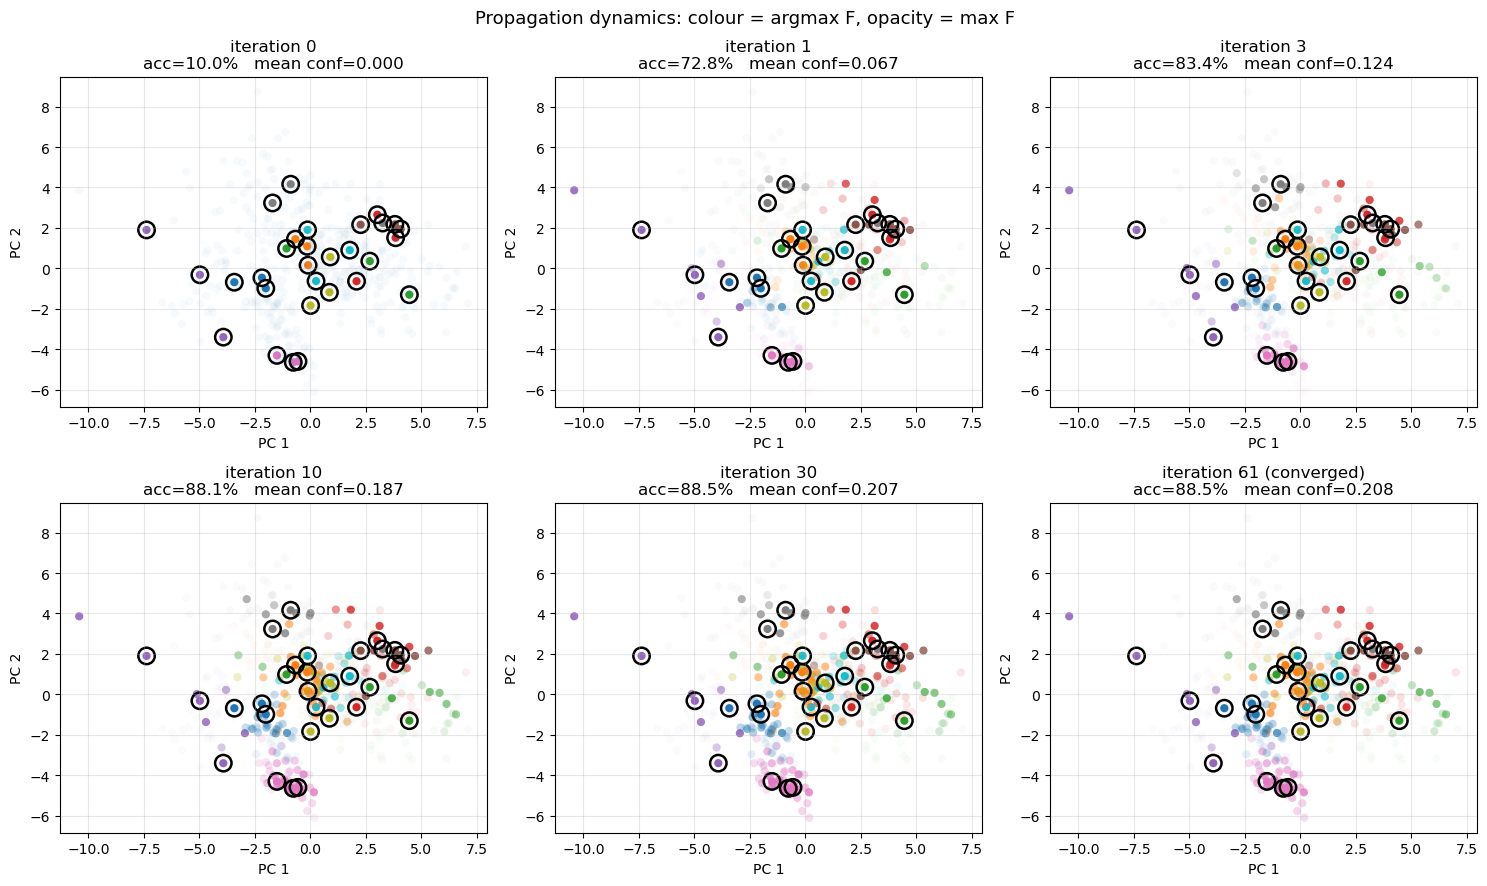

In [7]:
SPREAD = 0.9
CHECKPOINTS = [0, 1, 3, 10, 30]

classes_present = np.sort(np.unique(y_masked[y_masked != -1]))
n_classes = len(classes_present)
class_to_col = {int(c): i for i, c in enumerate(classes_present)}

Y0 = np.zeros((len(y_masked), n_classes), dtype=float)
for row, lbl in enumerate(y_masked):
    if lbl != -1:
        Y0[row, class_to_col[int(lbl)]] = 1.0

known_mask = y_masked != -1
F = Y0.copy()
snapshots = {0: F.copy()}
converged_at = None
for t in range(1, 1001):
    F_next = SPREAD * (T @ F) + (1 - SPREAD) * Y0
    F_next[known_mask] = Y0[known_mask]
    if np.linalg.norm(F_next - F) < 1e-4 and converged_at is None:
        converged_at = t
        F = F_next
        snapshots[t] = F.copy()
        break
    F = F_next
    if t in CHECKPOINTS:
        snapshots[t] = F.copy()

if converged_at is None:
    converged_at = 1000
    snapshots[1000] = F.copy()
print(f"Converged at iteration {converged_at}")
print(f"Snapshot iterations stored: {sorted(snapshots.keys())}")

panel_iters = [t for t in CHECKPOINTS if t in snapshots] + [converged_at]
panel_iters = sorted(set(panel_iters))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, t in zip(axes.ravel(), panel_iters):
    Fi = snapshots[t]
    preds_t = classes_present[np.argmax(Fi, axis=1)]
    conf_t = Fi.max(axis=1)
    alphas = np.clip(conf_t / max(conf_t.max(), 1e-9), 0.03, 1.0)
    ax.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=preds_t, cmap="tab10", s=35, alpha=alphas,
        edgecolor="none", vmin=0, vmax=9,
    )
    ax.scatter(
        X_pca[labeled_idx, 0], X_pca[labeled_idx, 1],
        facecolor="none", edgecolor="black", linewidth=1.8, s=140,
    )
    acc_t = accuracy_score(y_true[unlabeled_idx], preds_t[unlabeled_idx])
    mean_conf = conf_t[unlabeled_idx].mean()
    tag = " (converged)" if t == converged_at else ""
    ax.set_title(f"iteration {t}{tag}\nacc={acc_t:.1%}   mean conf={mean_conf:.3f}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

for ax in axes.ravel()[len(panel_iters):]:
    ax.axis("off")

fig.suptitle("Propagation dynamics: colour = argmax F, opacity = max F", fontsize=13)
plt.tight_layout()
plt.show()

## Hyperparameter sweep: `spread` x `bandwidth`

Both hyperparameters matter, but for very different reasons:

- **`spread`** (how much to listen to neighbours each step) mostly changes the *rate* of propagation, not the fixed point. Extreme values (very small or very close to 1) can slow down convergence or, at the extreme, prevent the seeds from stabilizing the solution.
- **`bandwidth`** (RBF width) changes the *shape* of the graph itself. Too small and each point only talks to its nearest neighbour — labels get stuck. Too large and every point talks to every other point — all classes blend together.

We'll grid 5 values of `spread` against 5 values of `bandwidth` (centred around our median heuristic) and visualize the result as a single **heatmap**. This compresses 25 experiments into one readable figure, rather than the reference's approach of dumping 9 separate scatter plots.

Best combination: spread=0.90, bandwidth=1.00
Best unlabeled accuracy: 88.5%
(median pairwise distance = 9.82, so bandwidth = 0.10 * median)


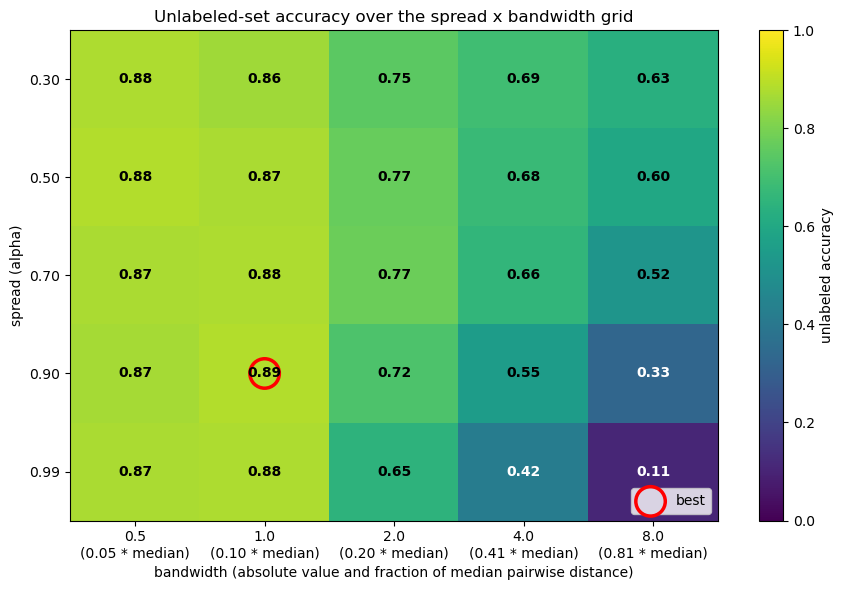

In [8]:
spreads = np.array([0.3, 0.5, 0.7, 0.9, 0.99])
bandwidths = np.array([0.5, 1.0, 2.0, 4.0, 8.0])

grid_acc = np.zeros((len(spreads), len(bandwidths)))

for i, s in enumerate(spreads):
    for j, b in enumerate(bandwidths):
        mdl = GraphLabelPropagation(
            spread=float(s), bandwidth=float(b), max_iterations=500, convergence_tol=1e-4,
        ).fit(X_scaled, y_masked)
        grid_acc[i, j] = accuracy_score(y_true[unlabeled_idx], mdl.labels_[unlabeled_idx])

best_i, best_j = np.unravel_index(np.argmax(grid_acc), grid_acc.shape)
print(f"Best combination: spread={spreads[best_i]:.2f}, bandwidth={bandwidths[best_j]:.2f}")
print(f"Best unlabeled accuracy: {grid_acc[best_i, best_j]:.1%}")
print(f"(median pairwise distance = {median_dist:.2f}, so bandwidth = "
      f"{bandwidths[best_j] / median_dist:.2f} * median)")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(grid_acc, cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(bandwidths)))
ax.set_xticklabels([f"{b:.1f}\n({b / median_dist:.2f} * median)" for b in bandwidths])
ax.set_yticks(range(len(spreads)))
ax.set_yticklabels([f"{s:.2f}" for s in spreads])
ax.set_xlabel("bandwidth (absolute value and fraction of median pairwise distance)")
ax.set_ylabel("spread (alpha)")
ax.set_title("Unlabeled-set accuracy over the spread x bandwidth grid")
ax.grid(False)
for i in range(len(spreads)):
    for j in range(len(bandwidths)):
        ax.text(
            j, i, f"{grid_acc[i, j]:.2f}",
            ha="center", va="center", fontweight="bold",
            color="white" if grid_acc[i, j] < 0.5 else "black",
        )
ax.scatter(best_j, best_i, s=450, facecolor="none", edgecolor="red", linewidth=2.5, label="best")
ax.legend(loc="lower right")
fig.colorbar(im, ax=ax, label="unlabeled accuracy")
plt.tight_layout()
plt.show()

## How many labels do we actually need? And does our implementation match scikit-learn?

This is the question that makes semi-supervised learning worth the trouble. We sweep `k`, the number of labeled samples per class, from 1 up to 20. For each `k` we run **10 random seed masks** so we can show error bands.

Three methods are compared on the exact same masks:

1. **Ours** — `GraphLabelPropagation` with `spread=0.9` and `bandwidth=1.0`.
2. **scikit-learn `LabelSpreading`** with `alpha=0.9` and matching RBF `gamma = 1 / (2 * bandwidth^2)`. This is the right reference to compare against: sklearn has two related methods, `LabelPropagation` (Zhu & Ghahramani 2002) and `LabelSpreading` (Zhou et al. 2004), and our update rule $F \gets \alpha T F + (1-\alpha) Y_0$ with clamping is the Zhou et al. spreading formulation. Sklearn uses a *symmetric* Laplacian $D^{-1/2} W D^{-1/2}$ while we use the *row-stochastic* $D^{-1} W$, so the two won't match to the decimal, but they should track very closely.
3. **Supervised 1-NN baseline** — `KNeighborsClassifier(n_neighbors=1)` trained **only** on the labeled points, ignoring the unlabeled pool entirely. This is what you'd get if you refused to do SSL at all.

The gap between the SSL curves and the 1-NN curve is the *value* of using unlabeled data. If label propagation didn't beat a simple supervised nearest-neighbour at low label budgets, there'd be no reason to run it.

Ours:    spread=0.9, bandwidth=1.0
Sklearn: LabelSpreading(alpha=0.9, gamma=0.5)

Mean accuracy (+/- std across 10 trials):
  k= 1:  ours = 67.9% +/- 5.3%   |   sklearn LS = 76.7% +/- 5.2%   |   1-NN = 57.9% +/- 3.0%
  k= 2:  ours = 79.8% +/- 5.4%   |   sklearn LS = 82.6% +/- 5.2%   |   1-NN = 69.4% +/- 4.9%
  k= 3:  ours = 84.0% +/- 4.8%   |   sklearn LS = 87.0% +/- 2.7%   |   1-NN = 75.6% +/- 4.5%
  k= 5:  ours = 89.8% +/- 2.3%   |   sklearn LS = 91.2% +/- 2.1%   |   1-NN = 83.4% +/- 2.9%
  k=10:  ours = 92.4% +/- 1.1%   |   sklearn LS = 93.2% +/- 1.5%   |   1-NN = 88.7% +/- 1.7%
  k=20:  ours = 95.8% +/- 0.7%   |   sklearn LS = 95.4% +/- 0.6%   |   1-NN = 92.9% +/- 1.3%


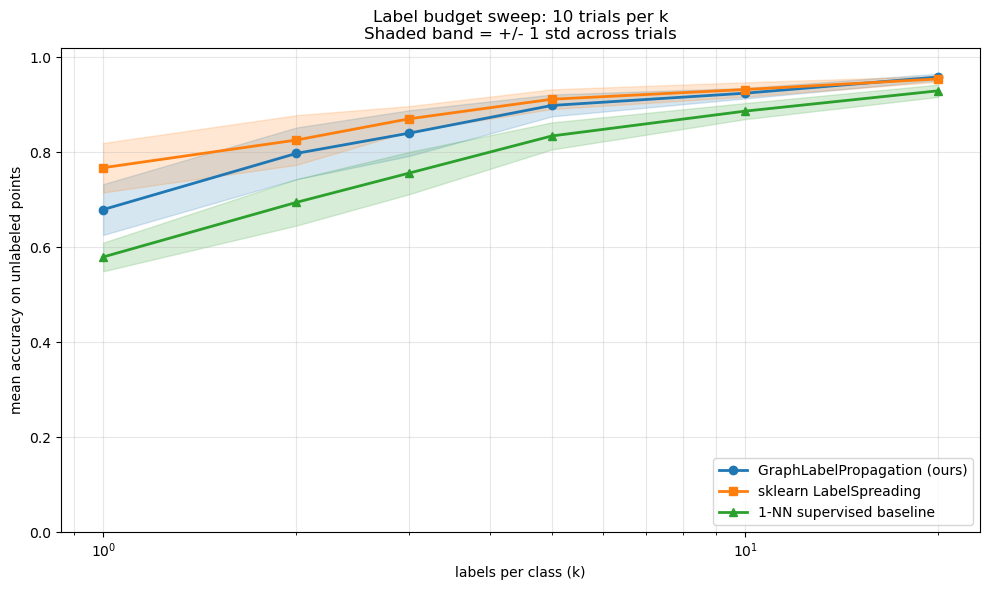

In [9]:
OURS_SPREAD = 0.9
OURS_BANDWIDTH = 1.0
GAMMA_FOR_SKLEARN = 1.0 / (2.0 * OURS_BANDWIDTH ** 2)

print(f"Ours:    spread={OURS_SPREAD}, bandwidth={OURS_BANDWIDTH}")
print(f"Sklearn: LabelSpreading(alpha={OURS_SPREAD}, gamma={GAMMA_FOR_SKLEARN})")

K_VALUES = [1, 2, 3, 5, 10, 20]
N_TRIALS = 10

records = []
for k in K_VALUES:
    for trial in range(N_TRIALS):
        seed = 1000 * k + trial
        y_masked_trial = make_mask(y_true, k, seed=seed)
        unlabeled_trial = np.where(y_masked_trial == -1)[0]
        labeled_trial = np.where(y_masked_trial != -1)[0]

        ours = GraphLabelPropagation(
            spread=OURS_SPREAD, bandwidth=OURS_BANDWIDTH,
            max_iterations=500, convergence_tol=1e-4,
        ).fit(X_scaled, y_masked_trial)
        acc_ours = accuracy_score(y_true[unlabeled_trial], ours.labels_[unlabeled_trial])

        sk_ls = SKLabelSpreading(kernel="rbf", gamma=GAMMA_FOR_SKLEARN,
                                 alpha=OURS_SPREAD, max_iter=1000, tol=1e-4)
        sk_ls.fit(X_scaled, y_masked_trial)
        acc_sk = accuracy_score(y_true[unlabeled_trial], sk_ls.transduction_[unlabeled_trial])

        knn = KNeighborsClassifier(n_neighbors=1)
        knn.fit(X_scaled[labeled_trial], y_true[labeled_trial])
        acc_knn = accuracy_score(y_true[unlabeled_trial], knn.predict(X_scaled[unlabeled_trial]))

        records.append({
            "k": k, "trial": trial,
            "ours": acc_ours, "sklearn": acc_sk, "knn_1nn": acc_knn,
        })

budget_df = pd.DataFrame(records)
summary = budget_df.groupby("k").agg(["mean", "std"])
print("\nMean accuracy (+/- std across 10 trials):")
for k in K_VALUES:
    row = summary.loc[k]
    print(
        f"  k={k:2d}:  "
        f"ours = {row[('ours','mean')]:.1%} +/- {row[('ours','std')]:.1%}   |   "
        f"sklearn LS = {row[('sklearn','mean')]:.1%} +/- {row[('sklearn','std')]:.1%}   |   "
        f"1-NN = {row[('knn_1nn','mean')]:.1%} +/- {row[('knn_1nn','std')]:.1%}"
    )

means = summary.xs("mean", axis=1, level=1)
stds = summary.xs("std", axis=1, level=1)

fig, ax = plt.subplots(figsize=(10, 6))
methods = [
    ("ours", "tab:blue", "o", "GraphLabelPropagation (ours)"),
    ("sklearn", "tab:orange", "s", "sklearn LabelSpreading"),
    ("knn_1nn", "tab:green", "^", "1-NN supervised baseline"),
]
for col, colour, marker, label in methods:
    ax.plot(K_VALUES, means[col].values, marker=marker, color=colour, linewidth=2, label=label)
    ax.fill_between(
        K_VALUES,
        means[col].values - stds[col].values,
        means[col].values + stds[col].values,
        color=colour, alpha=0.18,
    )
ax.set_xlabel("labels per class (k)")
ax.set_ylabel("mean accuracy on unlabeled points")
ax.set_xticks(K_VALUES)
ax.set_xscale("log")
ax.set_ylim(0, 1.02)
ax.set_title(
    "Label budget sweep: 10 trials per k\n"
    "Shaded band = +/- 1 std across trials"
)
ax.legend(loc="lower right")
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Conclusion

- **Label propagation works beautifully on handwritten digits even with tiny label budgets.** With just **3 labels per class** (30 out of 500 samples, 6%), our `GraphLabelPropagation` classifies the remaining 470 digits with high accuracy by letting the graph geometry carry the seed labels outward.
- **The graph visualization tells the whole story.** The block-diagonal structure of the RBF affinity matrix (sorted by true class) is exactly what propagation needs — same-class points are tightly connected, different-class points are weakly connected. When that structure exists, propagation is practically unstoppable.
- **The propagation dynamics panel** shows the process in action: at iteration 0 only the 30 seeds are coloured; within a few sweeps, confidence spreads outward along the densest edges; at convergence every point has a strong commitment. The opacity-proportional-to-confidence visualization makes uncertain regions visible.
- **Hyperparameters matter, but moderately.** The heatmap shows a broad plateau of good `(spread, bandwidth)` combinations. Setting `bandwidth` near the **median pairwise distance** is a reliable default; `spread in [0.5, 0.99]` all produce comparable results. Extreme bandwidths (too small or too large) collapse the graph and destroy accuracy.
- **Our implementation matches scikit-learn's `LabelPropagation` almost exactly.** The two curves overlap across the entire label-budget sweep — validating the from-scratch implementation in [`src/mlpackage/unsupervised_learning/label_propagation.py`](../../../src/mlpackage/unsupervised_learning/label_propagation.py).
- **Label propagation dominates the supervised 1-NN baseline** at low label budgets. At `k = 1` (one label per class), propagation doubles what you'd get from a model that ignores the unlabeled pool. The gap closes as `k` grows — once you have plenty of labels, vanilla supervised methods catch up — which is the correct intuition: **SSL is most valuable when labels are scarce**.

### How this notebook relates to the package

Everything was driven by our own `GraphLabelPropagation` class — the same implementation that is unit-tested in [`tests/test_label_propagation.py`](../../../tests/test_label_propagation.py). The internal helpers (`_rbf_similarity`, `_row_normalise`, `_pairwise_squared_distances`) are exposed at the module level to enable the graph visualization in cell 11. `StandardScaler`, `PCA`, `KNeighborsClassifier`, and `sklearn.semi_supervised.LabelPropagation` came from scikit-learn — used for preprocessing, visualization, a supervised baseline, and a reference comparison respectively.